In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.4 MB/s eta 0:00:00


In [2]:
import torchmetrics
import torch, matplotlib.pyplot as plt, pandas as pd, numpy as np, scipy, seaborn as sns
import torch.nn as nn
from torch import tensor, Tensor
from torch.nn import functional as F, Sequential, Linear, Softmax, Sigmoid, CrossEntropyLoss, MSELoss, ReLU, LeakyReLU

# **Intro to Deep Learning**

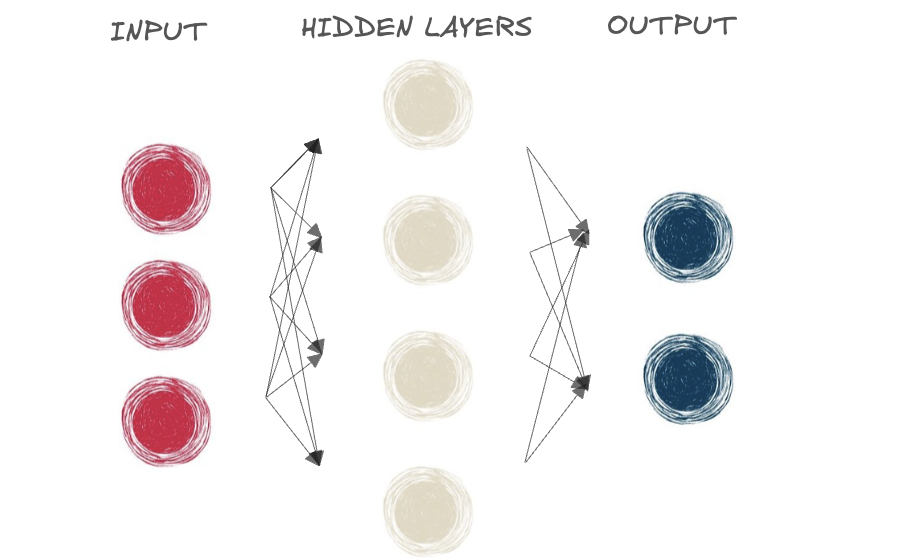

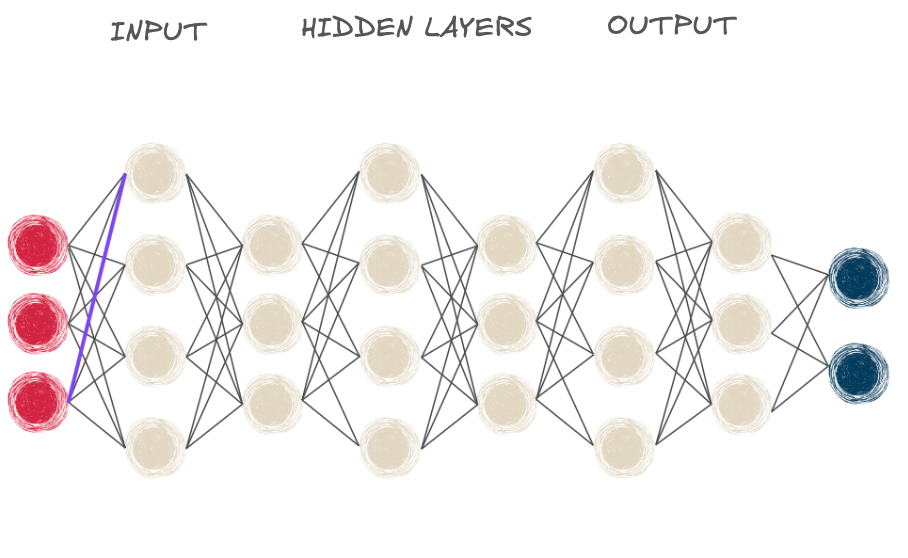

## **PyTorch tensors**

Tensor:
- Similar to array or matrix
- Building block of neural networks

In [ ]:
import torch

my_list = [[1, 2, 3], [4, 5, 6]]
tensor = torch.tensor(my_list)
tensor

tensor([[1, 2, 3],
        [4, 5, 6]])

### **Tensor shape**

In [ ]:
tensor.shape

torch.Size([2, 3])

### **Tensor data type**

In [ ]:
tensor.dtype

torch.int64

#### ***Exercise: Getting started with PyTorch tensors***

Tensors are PyTorch's core data structure and the foundation of deep learning. They're similar to NumPy arrays but have unique features.

Here you have a Python list named temperatures containing daily readings from two weather stations. Try converting this into a tensor!

#### ***Instructions***

- Begin by importing torch.
- Create a tensor from the Python list temperatures.

In [ ]:
import torch

temperatures = [[72, 75, 78], [70, 73, 76]]
temperatures = torch.tensor(temperatures)

print(temperatures)

tensor([[72, 75, 78],
        [70, 73, 76]])


#### ***Exercise: Checking and adding tensors***

While collecting temperature data, you notice the readings are off by two degrees. Add two degrees to the temperatures tensor after verifying its shape and data type with torch to ensure compatibility with the adjustment tensor.

#### **Instructions**


- Display the shape of the `adjustment` tensor.
- Display the data type of the `adjustment` tensor.
- Add the `temperatures` and `adjustment` tensors.

In [ ]:
adjustment = torch.tensor([[2, 2, 2], [2, 2, 2]])

print("Adjustment shape:", adjustment.shape)
print("Adjustment type:", adjustment.dtype)
print("Temperatures shape:", temperatures.shape)
print("Temperatures type:", temperatures.dtype)

corrected_temperatures = temperatures + adjustment
print("Corrected temperatures:", corrected_temperatures)

Adjustment shape: torch.Size([2, 3])
Adjustment type: torch.int64
Temperatures shape: torch.Size([2, 3])
Temperatures type: torch.int64
Corrected temperatures: tensor([[74, 77, 80],
        [72, 75, 78]])


## **Network without hidden layers**

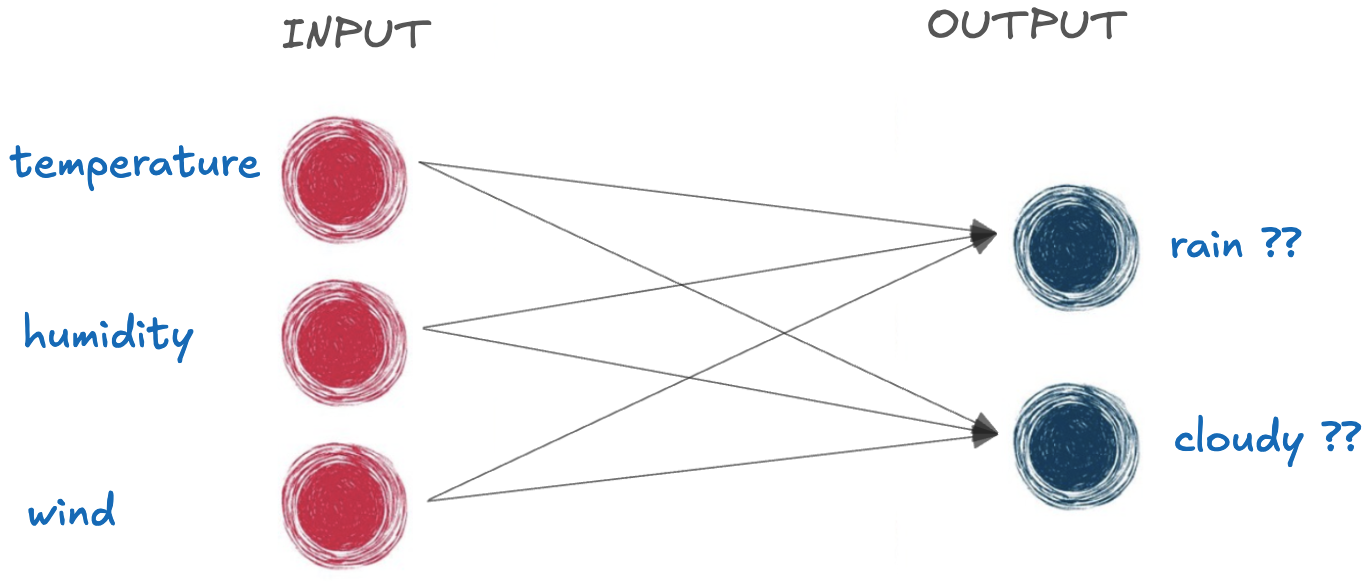

* Equivalent to linear model
* Input neurons = features
* Output neurons = classes

In [ ]:
from torch.nn import Linear
from torch import tensor

input_tensor = tensor([[0.3471, 0.4547, -0.2356]])
linear_layer = Linear(in_features=3, out_features=2)
output = linear_layer(input_tensor)
print(output)

tensor([[ 0.2882, -0.4060]], grad_fn=<AddmmBackward0>)


## **Weights and biases**

* Weights determine how much influence each input has on the neuron's output

In [ ]:
linear_layer.weight

Parameter containing:
tensor([[-0.3612,  0.1368, -0.3833],
        [-0.3806,  0.0465,  0.3274]], requires_grad=True)

In [ ]:
linear_layer.bias

Parameter containing:
tensor([ 0.2610, -0.2179], requires_grad=True)

# **Hidden layers and parameters**

## **Stacking layers with `nn.Sequential()`**

* Layers within **`nn.Sequential()`** are hidden layers.
* `n_features` and `n_classes` are defined by the dataset

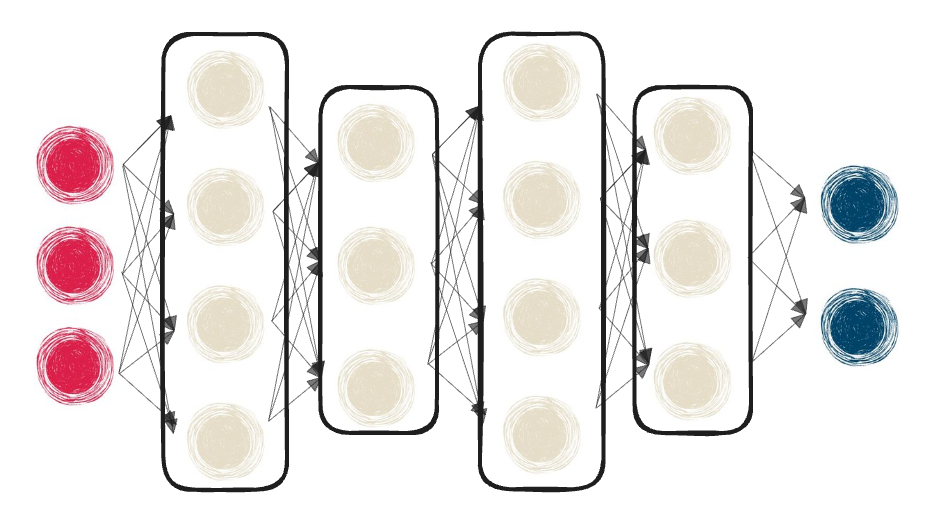

## **Parameters and model capacity**

In [ ]:
from torch.nn import Sequential, Linear

model = Sequential(Linear(8, 4), Linear(4, 2))

- First layer has 4 neurons, each neuron has 8+1 parameters. 9 $\times$ 4 = 36 parameters
- Second layer has 2 neurons, each neuronhas 4+1 parameters. 5 $\times$ 2 = 10 parameters

- 36 + 10 = 46 learnable parameters

In [ ]:
total = 0
for parameter in model.parameters():
    total += parameter.numel()
print(total)

46


#### ***Exercise: Your first neural network***

It's time for you to implement a small neural network containing ***two linear*** layers in sequence.

#### ***Instructions***

* Add a container for stacking layers in sequence.

In [ ]:
from torch import Tensor
from torch.nn import Sequential, Linear

input_tensor = Tensor([[2, 3, 6, 7, 9, 3, 2, 1]])

# Create a container for stacking linear layers
model = Sequential(Linear(8, 4), Linear(4, 1))
output = model(input_tensor)

print(output)

tensor([[-0.9689]], grad_fn=<AddmmBackward0>)


#### ***Exercise: Counting the number of parameters***

Deep learning models are famous for having a lot of parameters. With more parameters comes more computational complexity and longer training times, and a deep learning practitioner must know how many parameters their model has.

#### ***Instructions***

* Use `.numel()` to calculate by iterating through the model's parameters to updating the total variable.

In [ ]:
from torch.nn import Linear, Sequential

model = Sequential(Linear(9, 4),
                   Linear(4, 2),
                   Linear(2, 1))

total = 0
for p in model.parameters():
  total += p.numel()

print(f"The number of parameters in the model is {total}")

The number of parameters in the model is 53


# **Activation functions**

Activation functions add non-linearity to
the network
- **Sigmoid** for binary classification
- **Softmax** for multi-class classification

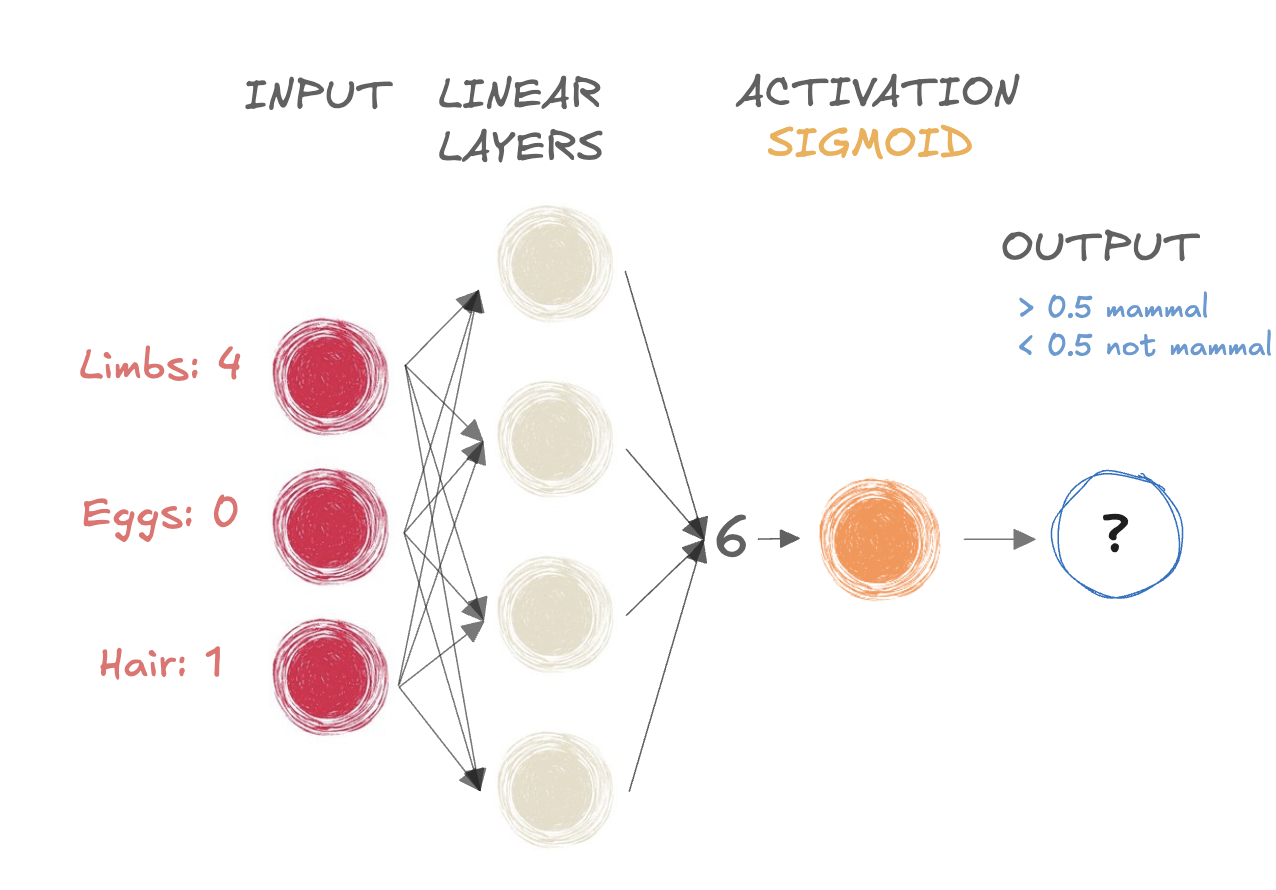

## **Sigmoid function**

Sigmoid as last step in network of linear layers is equivalent to traditional logistic regression

In [ ]:
from torch import tensor
from torch.nn import Sigmoid, Sequential, Linear

input = tensor([[6]])
sm = Sigmoid()
output = sm(input)
print(output) # value between 0 and 1

model = Sequential(Linear(6, 4), # First linear layer
                   Linear(4, 1), # Second linear layer
                   Sigmoid() # Sigmoid activation function
)

tensor([[0.9975]])


## **Softmax function**

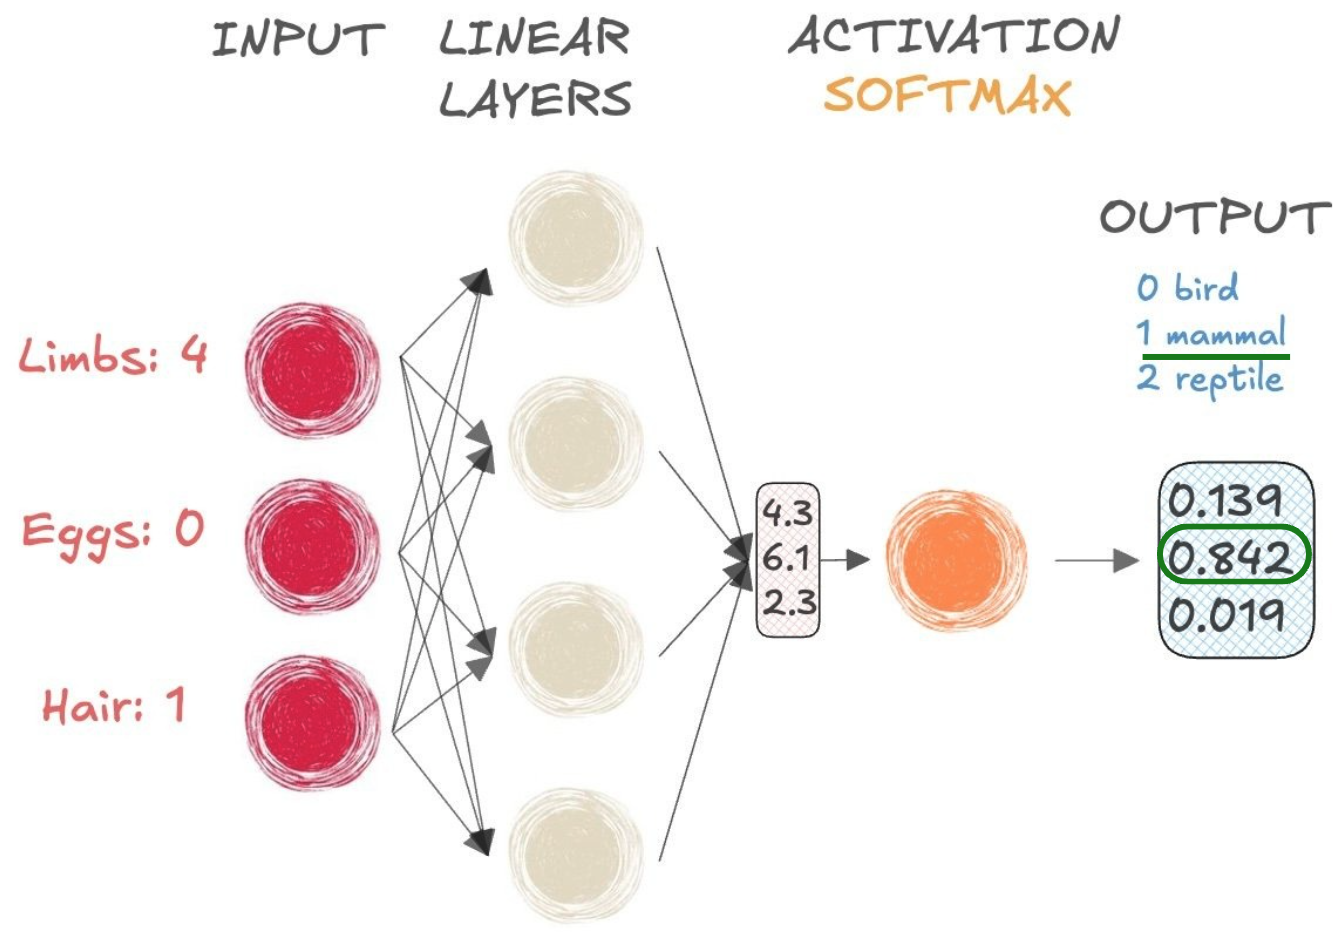

In [ ]:
from torch.nn import Softmax

input = tensor([[4.3, 6.1, 2.3]])
probabilities = Softmax(dim=-1) # -1 means last dimension
output = probabilities(input)
print(output)

tensor([[0.1392, 0.8420, 0.0188]])


# **Running a forward pass**

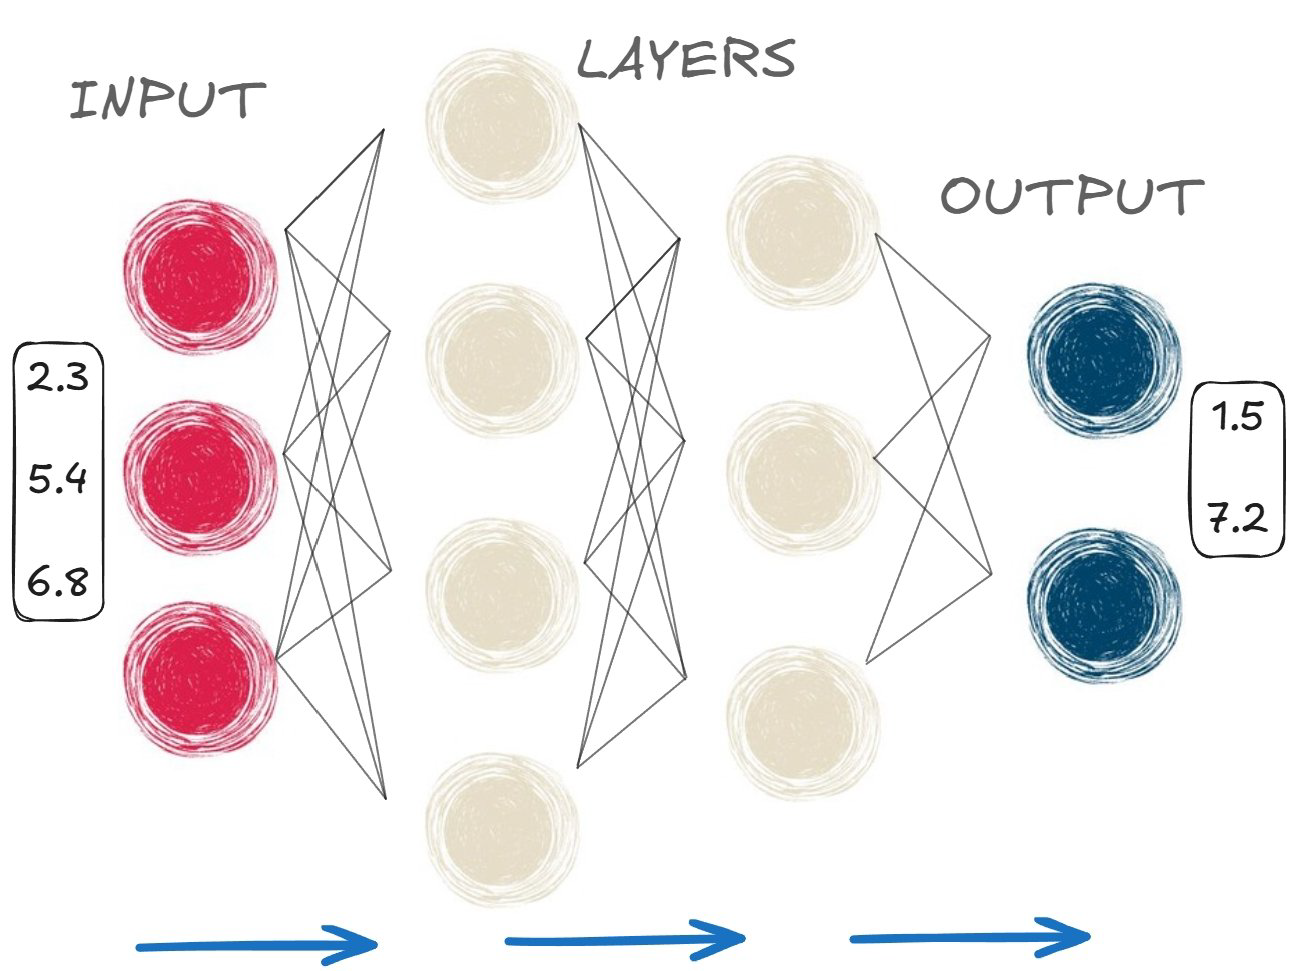





- Input data flows through layers
- Calculations performed at each layer
- Final layer generates outputs

## **Binary classification: forward pass**

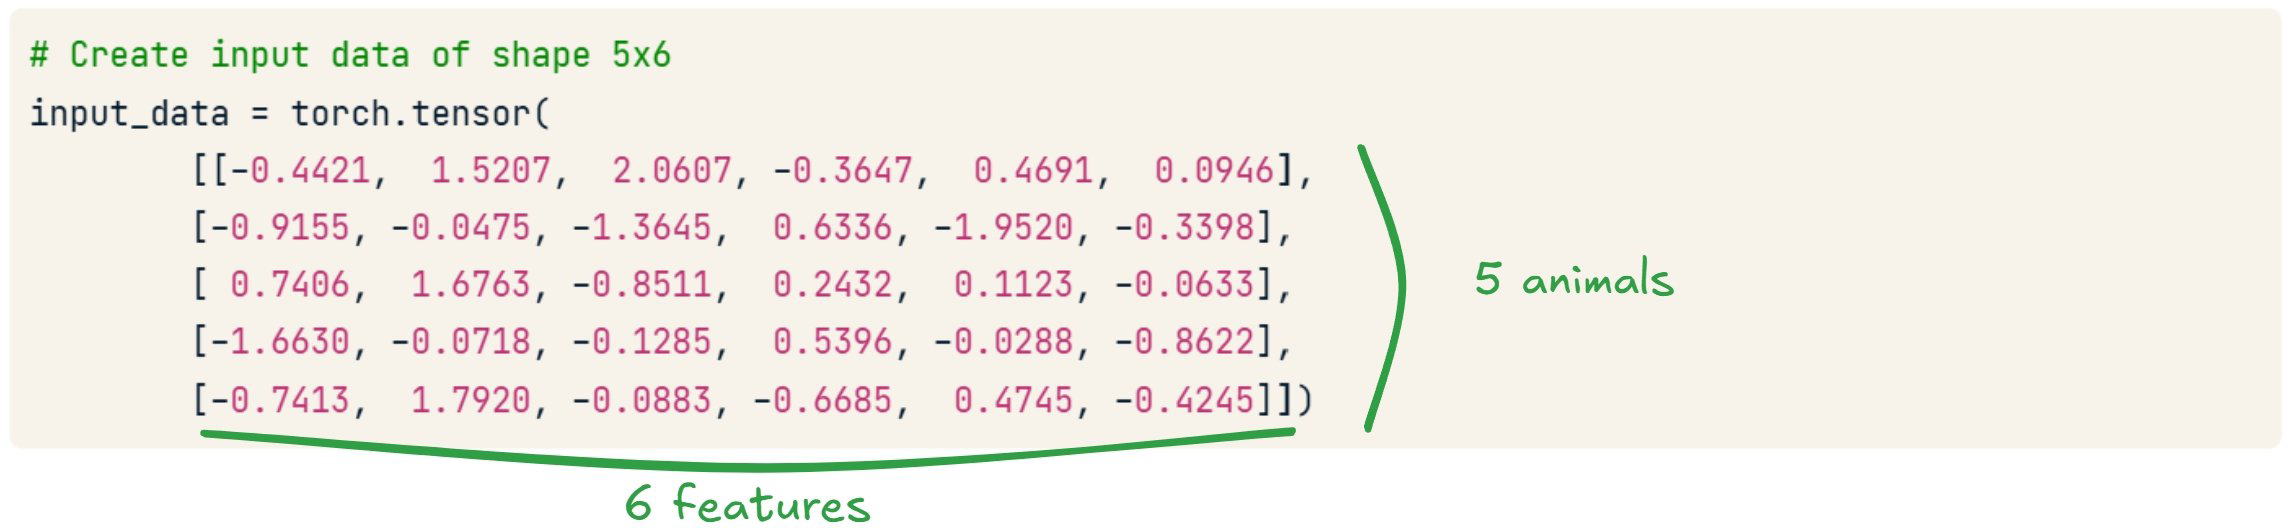

In [ ]:
from torch.nn import Sequential, Linear, Sigmoid, Softmax
from torch import tensor

# Create input data of shape 5x6
input = tensor([[-0.4421,  1.5207,  2.0607, -0.3647,  0.4691,  0.0946],
                [-0.9155, -0.0475, -1.3645,  0.6336, -1.9520, -0.3398],
                [ 0.7406,  1.6763, -0.8511,  0.2432,  0.1123, -0.0633],
                [-1.6630, -0.0718, -0.1285,  0.5396, -0.0288, -0.8622],
                [-0.7413,  1.7920, -0.0883, -0.6685,  0.4745, -0.4245]])


# Create binary classification model
model = Sequential(Linear(6, 4), # First linear layer
                   Linear(4, 1), # Second linear layer
                   Sigmoid() # Sigmoid activation function
)

print(model(input))

tensor([[0.3670],
        [0.5577],
        [0.4039],
        [0.5639],
        [0.4405]], grad_fn=<SigmoidBackward0>)


- Output: five probabilities between 0 and 1, one for observation
- Classification (0.5 threshold):
Class = 1 for values ≥ 0.5
- Class = 0  for values < 0.5

## **Multi-class classification: forward pass**

- Class 1 - mammal, class 2 - bird, class 3 - reptile

In [ ]:
from torch.nn import Linear, Sequential, Softmax
from torch import tensor

n_classes = 3

model = Sequential(Linear(6, 4), # First linear layer
                   Linear(4, n_classes), # Second linear layer
                   Softmax(dim=-1) # Softmax activation
)

output = model(input)
print(output.shape)
print(output) # probabilities for each observation

torch.Size([5, 3])
tensor([[0.4771, 0.2414, 0.2815],
        [0.5217, 0.1912, 0.2871],
        [0.3860, 0.3713, 0.2426],
        [0.4591, 0.2368, 0.3041],
        [0.4364, 0.2957, 0.2679]], grad_fn=<SoftmaxBackward0>)


## **Regression: forward pass**

In [ ]:
from torch.nn import Linear, Sequential, Softmax
from torch import tensor

model = Sequential(Linear(6, 4), # First linear layer
                   Linear(4, 1) # Second linear layer
)

# Pass input data through model
output = model(input)

# Return output
print(output)

tensor([[-0.0453],
        [-0.4805],
        [-0.8218],
        [-0.2992],
        [-0.0850]], grad_fn=<AddmmBackward0>)


#### ***Exercise***

Building a binary classifier in PyTorch
Recall that a small neural network with a single linear layer followed by a sigmoid function is a binary classifier. It acts just like a logistic regression.

Practice building this small network and interpreting the output of the classifier.

#### ***Instructions***

- Create a neural network that takes a **1x8** tensor as input and outputs a single value for binary classification.
- Pass the output of the linear layer to a **sigmoid** to produce a probability.

In [ ]:
from torch import Tensor
from torch.nn import Sequential, Linear, Sigmoid

input_tensor = Tensor([[3, 4, 6, 2, 3, 6, 8, 9]])

# Implement a small neural network for binary classification
model = Sequential(Linear(8, 1), Sigmoid())
output = model(input_tensor)
print(output)

tensor([[0.2834]], grad_fn=<SigmoidBackward0>)


 The sigmoid output is always between 0 and 1.  However, it is produced from an untrained model so it is not yet meaningful (as we may have already noticed that the result changes every time).

 #### ***Exercise: From regression to multi-class classification****

The models you have seen for binary classification, multi-class classification and regression have all been similar, barring a few tweaks to the model.

Start building a model for **regression**, and then tweak the model to perform a **multi-class classification**.

#### ***Instructions***

- Create a **4-layer** linear network that takes **11 input features** from `input_tensor` and produces a **single** regression output.

- Update the network provided to perform a **multi-class** classification with **four** outputs.

In [ ]:
from torch import Tensor
from torch.nn import Sequential, Linear, Softmax

input_tensor = Tensor([[3, 4, 6, 7, 10, 12, 2, 3, 6, 8, 9]])

model = Sequential(Linear(11, 20),
                   Linear(20, 12),
                   Linear(12, 6),
                   Linear(6, 4), # Linear(6, 1) for the first question
                   Softmax(dim=-1))

output = model(input_tensor)
print(output)

tensor([[0.2080, 0.2795, 0.2467, 0.2659]], grad_fn=<SoftmaxBackward0>)


# **Using loss functions to assess model predictions**

- $y$ is a single **integer** (class label\ ground truth)
  - e.g. $y = 0$ when $y$  is a mammal
  - One-hot encoding converts an integer $y$ to a tensor of zeros and ones

  - 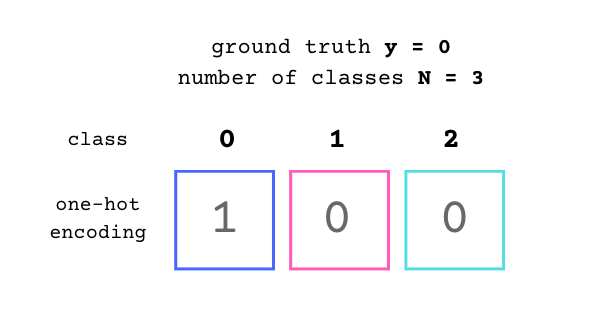
- $\hat{y}$ is a tensor (prediction <u>***before***</u> softmax)
   - If N is the number of classes, e.g. N = 3
   - $\hat{y}$ is a tensor with N dimensions,
     - e.g. = `[-5.2, 4.6, 0.8]`

In [ ]:
from torch.nn import functional as F

# 3 classes multiclass classification

for i in range(3):
    print(F.one_hot(tensor(i), num_classes=3))

tensor([1, 0, 0])
tensor([0, 1, 0])
tensor([0, 0, 1])


## **Cross entropy loss in PyTorch**

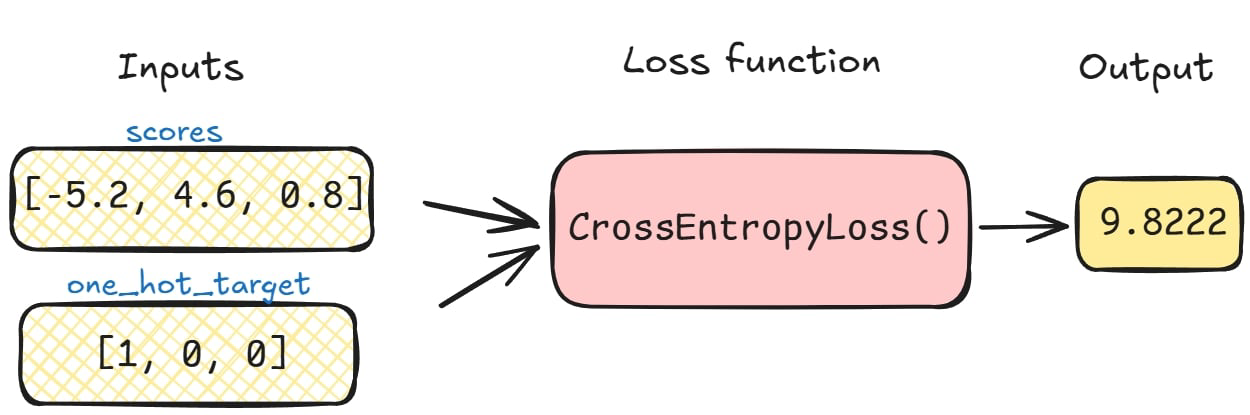

In [ ]:
from torch.nn import CrossEntropyLoss
from torch import tensor

scores = tensor([-5.2, 4.6, 0.8])
one_hot_target = tensor([1, 0, 0])
criterion = CrossEntropyLoss()

print(criterion(scores.double(), one_hot_target.double()))

tensor(9.8222, dtype=torch.float64)


#### ***Exercise: Creating one-hot encoded labels***

One-hot encoding converts a single integer label into a vector with N elements, where N is the number of classes. This vector contains zeros and a one at the correct position.

In this exercise, you'll manually create a one-hot encoded vector for y, and then use PyTorch to simplify the process. Your dataset has three classes (0, 1, 2).

#### ***Instructions***

* Manually one-hot encode the ground truth label `y` using the provided NumPy array and save it as `one_hot_numpy`.
* Use PyTorch to one-hot encode `y` and save it as `one_hot_pytorch`.

In [ ]:
from torch.nn import functional as F
from torch import tensor
import numpy as np

y = 1
num_classes = 3

# Create the one-hot encoded vector using NumPy
one_hot_numpy = np.array([0, 1, 0])

# Create the one-hot encoded vector using PyTorch
one_hot_pytorch = F.one_hot(tensor(y), num_classes=3)

print("One-hot vector using NumPy:", one_hot_numpy)
print("One-hot vector using PyTorch:", one_hot_pytorch)

One-hot vector using NumPy: [0 1 0]
One-hot vector using PyTorch: tensor([0, 1, 0])


#### ***Exercise: Calculating cross entropy loss***

Cross-entropy loss is a widely used method to measure classification loss. In this exercise, you’ll calculate cross-entropy loss in PyTorch using:

- `y`: the ground truth label.
- `scores`: a vector of predictions <u>***before***</u> softmax.

Loss functions help neural networks learn by measuring prediction errors. Create a one-hot encoded vector for `y`, define the cross-entropy loss function, and compute the loss using `scores` and the encoded label. The result will be a single float representing the sample's loss.

#### Instructions

- Create the one-hot encoded vector of the ground truth label `y`, with 4 features (one for each class), and assign it to `one_hot_label`.

- Create the cross entropy loss function and store it as `criterion`.

- Calculate the cross entropy loss using the `one_hot_label` vector and the `scores` vector, by calling the `loss_function` you created.

In [ ]:
from torch import tensor
from torch.nn import functional as F, CrossEntropyLoss

y = [2]
scores = tensor([[0.1, 6.0, -2.0, 3.2]])

one_hot_label = F.one_hot(tensor(y), num_classes=4)
criterion = CrossEntropyLoss()
loss = criterion(scores.double(), one_hot_label.double())
print(loss)

tensor(8.0619, dtype=torch.float64)


# **Using derivatives to update model parameters**


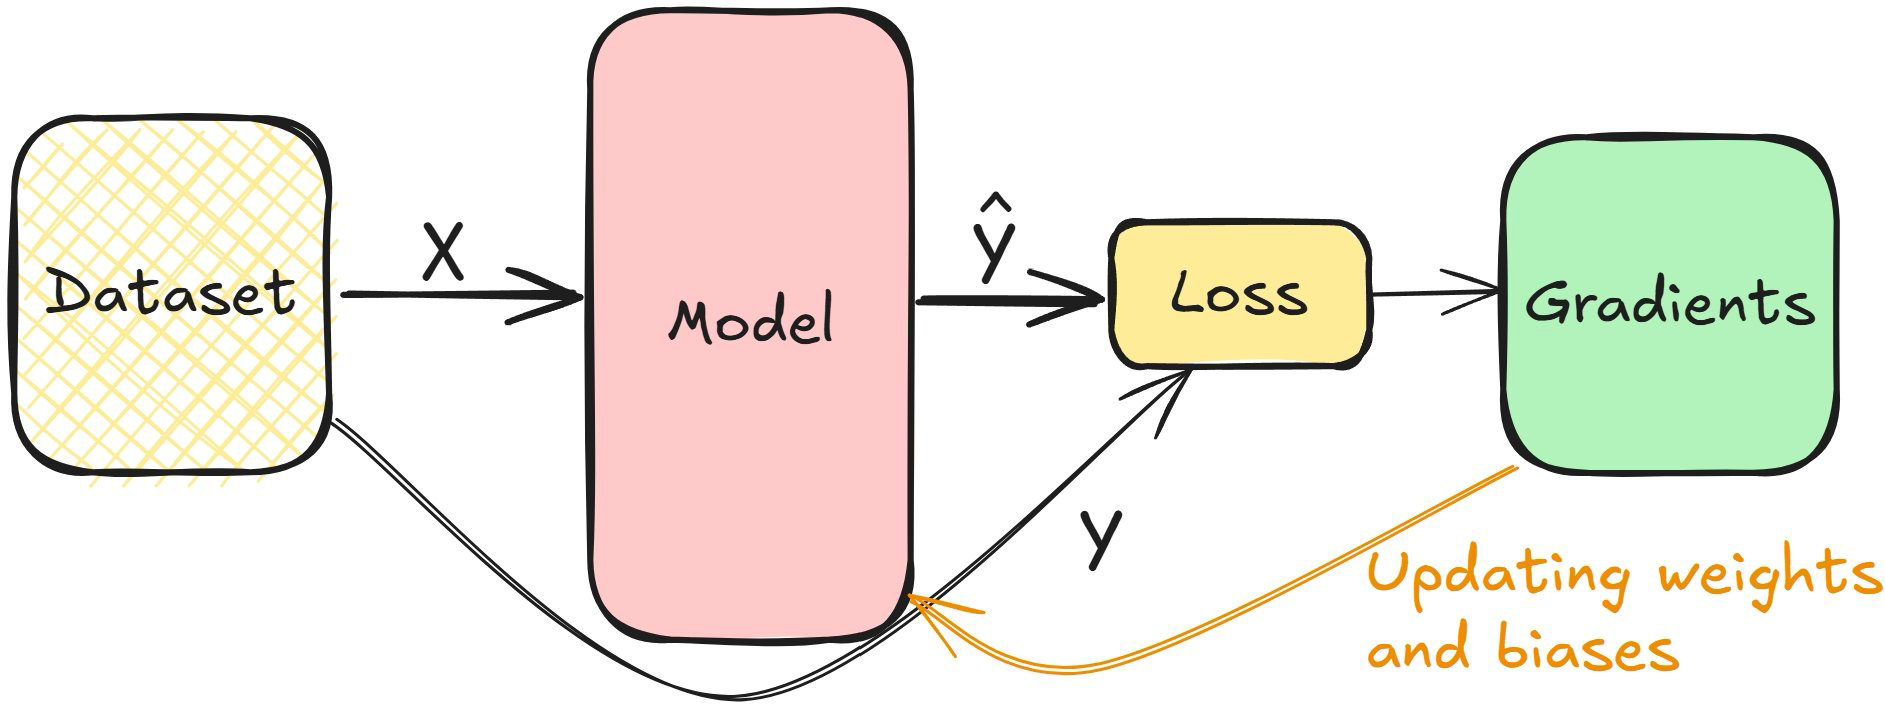

## **Backpropagation in PyTorch**

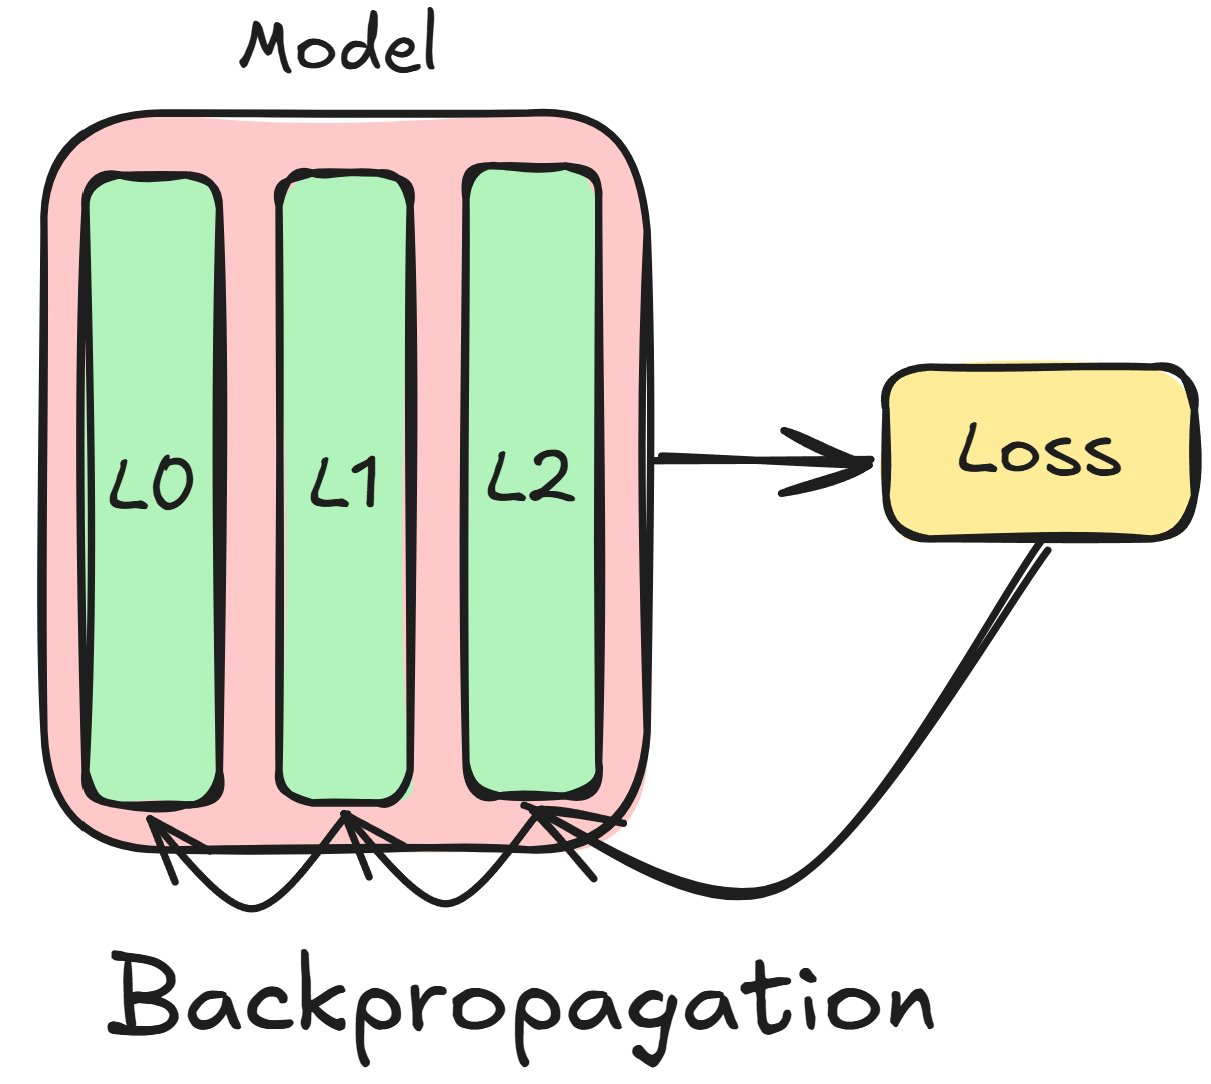

In [ ]:
from torch.nn import Sequential, Linear, CrossEntropyLoss

# Run a forward pass
model = Sequential(Linear(16, 8),
                   Linear(8, 4),
                   Linear(4, 2))

prediction = model(sample)

# Calculate the loss and gradients
criterion = CrossEntropyLoss()
loss = criterion(prediction, target)
loss.backward()

# Access each layer's gradients
model[0].weight.grad
model[0].bias.grad
model[1].weight.grad
model[1].bias.grad
model[2].weight.grad
model[2].bias.grad

## **Gradient descent**

In [ ]:
from torch import optim

# Create the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001)

# Perform parameter updates
optimizer.step()

#### ***Exercise: Accessing the model parameters***

A PyTorch model created with the **`nn.Sequential()`** is a module that contains the different layers of your network. Recall that each layer parameter can be accessed by indexing the created model directly. In this exercise, you will practice accessing the parameters of different linear layers of a neural network.

#### Instructions

* Access the `weight` parameter of the first linear layer.
* Access the `bias` parameter of the second linear layer.

In [ ]:
from torch.nn import Sequential, Linear

model = Sequential(Linear(16, 8),
                      Linear(8, 2))

# Access the weight of the first linear layer
weight_0 = model[0].weight
print("Weight of the first layer:", weight_0)

# Access the bias of the second linear layer
bias_1 = model[1].bias
print("Bias of the second layer:", bias_1)

Weight of the first layer: Parameter containing:
tensor([[ 0.0940, -0.1092,  0.1082,  0.1848,  0.2090,  0.1621, -0.0212, -0.1347,
          0.0179,  0.1774,  0.1233,  0.0844, -0.0790,  0.2378, -0.1870, -0.2231],
        [ 0.1397,  0.2254,  0.2031,  0.1268,  0.2007, -0.2253, -0.1051, -0.0798,
          0.0217, -0.2021,  0.1311,  0.2487, -0.0378,  0.1693,  0.1083,  0.1958],
        [-0.0721, -0.2105, -0.2037, -0.2106, -0.0930,  0.1916, -0.2246,  0.2398,
          0.0249, -0.0495, -0.0797, -0.1424,  0.2444,  0.0743,  0.0220, -0.0431],
        [-0.0009, -0.0415,  0.1478,  0.2355, -0.2015, -0.1066,  0.0200,  0.2222,
          0.1313,  0.0790, -0.1693, -0.1531,  0.0008, -0.0570, -0.0405,  0.0146],
        [-0.2068,  0.1183,  0.1517,  0.1545,  0.0276, -0.0620,  0.2000,  0.2402,
          0.2279,  0.0394, -0.1953,  0.0869,  0.0766, -0.0896, -0.0396, -0.0130],
        [-0.0791,  0.1617, -0.1318,  0.0221,  0.2190, -0.1956, -0.0502, -0.1564,
          0.2263, -0.0655,  0.2165, -0.0322, -0.2146,  

#### ***Exercise: Updating the weights manually***

Now that you know how to access weights and biases, you will manually perform the job of the PyTorch optimizer. While PyTorch automates this, practicing it manually helps you build intuition for how models learn and adjust. This understanding will be valuable when debugging or fine-tuning neural networks.

A neural network of three layers has been created and stored as the `model` variable. This network has been used for a forward pass and the loss and its derivatives have been calculated. A default learning rate, `lr`, has been chosen to scale the gradients when performing the update.

#### ***Instructions***

- Create the gradient variables by accessing the local gradients of each weight tensor.

- Update the weights using the gradients scaled by the learning rate.

In [ ]:
weight0 = model[0].weight
weight1 = model[1].weight
weight2 = model[2].weight

# Access the gradients of the weight of each linear layer
grads0 = weight0.grad
grads1 = weight1.grad
grads2 = weight2.grad

# Update the weights using the learning rate and the gradients
weight0 = weight0 - lr*grads0
weight1 = weight1 - lr*grads1
weight2 = weight2 - lr*grads2

#### ***ExerciseUsing the PyTorch optimizer***

Earlier, you manually updated the weight of a network, gaining insight into how training works behind the scenes. However, this method isn’t scalable for deep networks with many layers.

Thankfully, PyTorch provides the SGD optimizer, which automates this process efficiently in just a few lines of code. Now, you’ll complete the training loop by updating the weights using a PyTorch optimizer.

A neural network has been created and provided as the `model` variable. This model was used to run a forward pass and create the tensor of predictions `pred`. The one-hot encoded tensor is named `target` and the cross entropy loss function is stored as `criterion`.

#### Instructions

- Use `optim` to create an SGD optimizer with a learning rate of your choice (must be less than one) for the `model` provided.

- Update the model's parameters using the optimizer.

In [ ]:
from torch import tensor, optim
from torch.nn import CrossEntropyLoss, Sequential, Linear

model = Sequential(Linear(5, 2), Linear(2, 2))
input = torch.randn(1, 5)
pred = model(input)
target = tensor([1])


optimizer = optim.SGD(model.parameters(), lr=0.001)

criterion = CrossEntropyLoss()
loss = criterion(pred, target)
loss.backward()


optimizer.step()


# **Tensor Dataset**


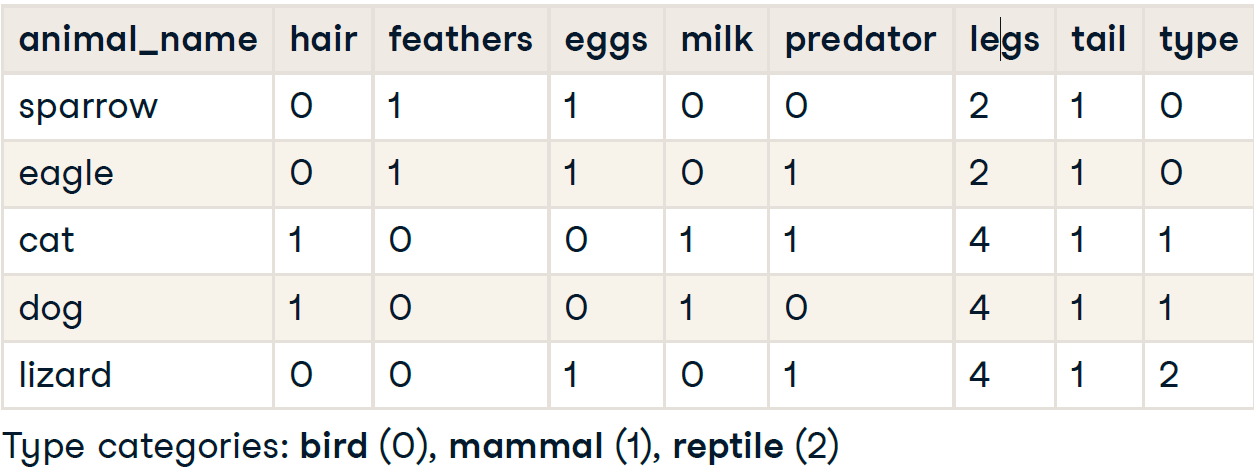


In [ ]:
from torch import tensor
from torch.utils.data import TensorDataset, DataLoader

# 5 animals 6 features
X = np.array([[0, 1, 1, 0, 0, 2, 1],
              [0, 1, 1, 0, 1, 2, 1],
              [1, 0, 0, 1, 1, 4, 1],
              [1, 0, 0, 1, 0, 4, 1],
              [0, 0, 1, 0, 1, 4, 1]])

# 3 types
y = np.array([0, 0, 1, 1, 2])

# Instantiate dataset class
dataset = TensorDataset(tensor(X), tensor(y))

# Access an individual sample
# Animal 1
input_sample, label_sample = dataset[1]
print('input sample:', input_sample)
print('label sample:', label_sample)

input sample: tensor([0, 1, 1, 0, 1, 2, 1])
label sample: tensor(0)


## **DataLoader**

In [ ]:
# how many samples are included in each iteration
batch_size = 2

# improve model generalization
shuffle = True

# Create a DataLoader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

for batch_inputs, batch_labels in dataloader:
    print('batch_inputs:', batch_inputs)
    print('batch_labels:', batch_labels)

batch_inputs: tensor([[0, 0, 1, 0, 1, 4, 1],
        [0, 1, 1, 0, 0, 2, 1]])
batch_labels: tensor([2, 0])
batch_inputs: tensor([[1, 0, 0, 1, 1, 4, 1],
        [1, 0, 0, 1, 0, 4, 1]])
batch_labels: tensor([1, 1])
batch_inputs: tensor([[0, 1, 1, 0, 1, 2, 1]])
batch_labels: tensor([0])


#### ***Exercise: Using TensorDataset***

Structuring your data into a dataset is one of the first steps in training a PyTorch neural network. `TensorDataset` simplifies this by converting NumPy arrays into a format PyTorch can use.

In this exercise, you'll create a `TensorDataset` using the preloaded `animals` dataset and inspect its structure.

#### ***Instructions***

- Convert `X` and `y` into tensors and create a `TensorDataset`.
- Access and print the first sample.

In [ ]:
import torch
from torch.utils.data import TensorDataset

X = animals.iloc[:, 1:-1].to_numpy()
y = animals.iloc[:, -1].to_numpy()

# Create a dataset
dataset = TensorDataset(torch.tensor(X), torch.tensor(y))

# Print the first sample
input_sample, label_sample = dataset[0]
print('Input sample:', input_sample)
print('Label sample:', label_sample)

#### **Exercise: Using DataLoader**

The `DataLoader` class is essential for efficiently handling large datasets. It speeds up training, optimizes memory usage, and stabilizes gradient updates, making deep learning models more effective.

Now, you'll create a PyTorch `DataLoader` using the `dataset` from the previous exercise and see it in action.

#### ***Instructions***

- Create a `DataLoader` using `dataset`, setting a batch size of **two** and enabling shuffling.
- Iterate through the `DataLoader` and print each batch of inputs and labels.

In [ ]:
from torch.utils.data import DataLoader

# Create a DataLoader

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Iterate over the dataloader
for batch_inputs, batch_labels in dataloader:
    print('batch_inputs:', batch_inputs)
    print('batch_labels:', batch_labels)

# **Training Neural Network**

1. Create a model'
2. Choose a loss function
3. Define a dataset
4. Set an optimizer
5. Run a training loop

      - calculate loss (forward pass)
      - compute gradients (back propagation)
      - update model parameters

### **Data Science Salary Dataset**

- Features: categorical
- Target: salary

```
experience_level employment_type remote_ratio company_size salary_in_usd
0                 0                 0.5            1           0.036
1                 0                 1.0            2           0.133
2                 0                 0.0            1           0.234
1                 0                 1.0            0           0.076
2                 0                 1.0            1           0.170
```



## **Mean Squared Error**

In [ ]:
def mean_squared_loss(prediction, target):
    return np.mean((prediction - target)**2)

### **Pytorch MSE**

In [ ]:
from torch.nn import MSELoss

criterion = MSELoss()
loss = criterion(prediciton, target)

## **Before the training loop**

In [37]:
from torch import tensor
from torch.nn import Sequential, Linear, MSELoss
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd


data = {
    "experience_level": [0, 1, 2, 1, 2],
    "employment_type": [0, 0, 0, 0, 0],
    "remote_ratio": [0.5, 1.0, 0.0, 1.0, 1.0],
    "company_size": [1, 2, 1, 0, 1],
    "salary_in_usd": [0.036, 0.133, 0.234, 0.076, 0.170],
}

df = pd.DataFrame(data)
features = df.drop(columns="salary_in_usd").values
target = df["salary_in_usd"].values

dataset = TensorDataset(tensor(features).float(), tensor(target).float())
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

model = Sequential(Linear(4, 2), Linear(2, 1))

criterion = MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

## **The training loop**

In [40]:
num_epochs = 5
for epoch in range(num_epochs):
    for data in dataloader:
        # Set the gradients to zero
        optimizer.zero_grad()

        # Get feature and target from the data loader
        feature, target = data

        # Run a forward pass
        pred = model(feature)

        # Compute loss and gradients
        loss = criterion(pred, target.unsqueeze(1))
        loss.backward()

        # Update the parameters
        optimizer.step()

#### ***Exercise: Using the MSELoss***

For **regression** problems, you often use **Mean Squared Error (MSE)** as a loss function instead of cross-entropy. MSE calculates the squared difference between predicted values (`y_pred`) and actual values (`y`). Now, you'll compute MSE loss using both NumPy and PyTorch.


#### Instructions

- Calculate the MSE loss using **NumPy**.
- Create an MSE loss function using **PyTorch**.
- Convert `y_pred` and `y` to tensors, then calculate the MSE loss as `mse_pytorch`.

In [ ]:
import numpy as np
from torch import tensor
from torch.nn import MSELoss

y_pred = np.array([3, 5.0, 2.5, 7.0])
y = np.array([3.0, 4.5, 2.0, 8.0])

# Calculate MSE using NumPy
mse_numpy = np.mean((y_pred-y)**2)

# Create the MSELoss function in PyTorch
criterion = MSELoss()

# Calculate MSE using PyTorch
mse_pytorch = criterion(torch.tensor(y_pred), torch.tensor(y))

print("MSE (NumPy):", mse_numpy)
print("MSE (PyTorch):", mse_pytorch)

MSE (NumPy): 0.375
MSE (PyTorch): tensor(0.3750, dtype=torch.float64)


#### ***Exercise: Writing a training loop***

In scikit-learn, the training loop is wrapped in the **`.fit()`** method, while in PyTorch, it's set up manually. While this adds flexibility, it requires a custom implementation.

In this exercise, you'll create a loop to train a model for salary prediction.

The `show_results()` function is provided to help you visualize some sample predictions.

The following variables have been created:

- `num_epochs`, containing the number of epochs (set to 5);
- `dataloader`, containing the dataloader;
- `model`, containing the neural network;
- `criterion`, containing the loss function,
- `nn.MSELoss()`;
- `optimizer`, containing the SGD optimizer.

#### Instructions

- Write a for loop that iterates over the dataloader; this should be nested within a for loop that iterates over a range equal to the number of epochs.
- Set the gradients of the optimizer to zero.
- Compute the loss using the `criterion()` function and the gradients.

In [62]:
def show_results(model, dataloader):
    model.eval()
    iter_loader = iter(dataloader)
    for _ in range(3):
        feature, target = next(iter_loader)
        preds = model(feature)
        for p, t in zip(preds, target):
            print(f'Ground truth salary: {t.item():.3f}. Predicted salary: {p.item():.3f}.')

In [65]:
from torch import tensor
from torch.nn import Sequential, Linear, MSELoss
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd

df = pd.read_csv('salary.csv').drop(columns="Unnamed: 0")
features = df.drop(columns="salary_in_usd").values
target = df["salary_in_usd"].values

dataset = TensorDataset(tensor(features).float(), tensor(target).float())
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

model = Sequential(Linear(4, 2), Linear(2, 1))

criterion = MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
num_epochs = 5
#############################################################################

# Loop over the number of epochs and the dataloader
for i in range(num_epochs):
  for data in dataloader:
    # Set the gradients to zero
    optimizer.zero_grad()
    # Run a forward pass
    feature, target = data
    prediction = model(feature)
    # Compute the loss
    loss = criterion(prediction, target.unsqueeze(1))
    # Compute the gradients
    loss.backward()
    # Update the model's parameters
    optimizer.step()

show_results(model, dataloader)

Ground truth salary: 0.321. Predicted salary: 0.101.
Ground truth salary: 0.316. Predicted salary: 0.233.
Ground truth salary: 0.067. Predicted salary: 0.262.
Ground truth salary: 0.065. Predicted salary: 0.274.
Ground truth salary: 0.103. Predicted salary: 0.394.
Ground truth salary: 0.225. Predicted salary: 0.101.
Ground truth salary: 0.027. Predicted salary: -0.093.
Ground truth salary: 0.283. Predicted salary: 0.221.
Ground truth salary: 0.234. Predicted salary: 0.353.
Ground truth salary: 0.221. Predicted salary: 0.233.
Ground truth salary: 0.267. Predicted salary: 0.101.
Ground truth salary: 0.095. Predicted salary: 0.089.


# **ReLU (Rectified Linear Unit) activation functions**

$$f(x) = \max(x, 0)$$

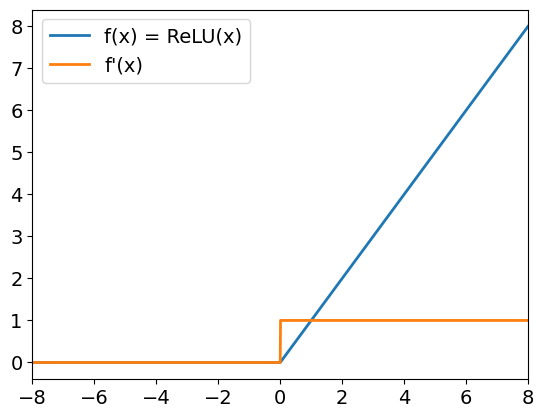

## **Leaky ReLU**

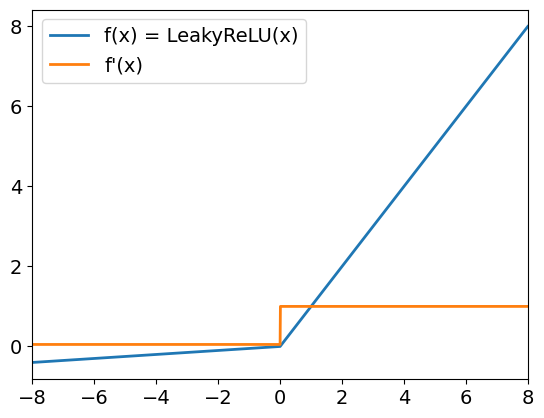

In [ ]:
from torch.nn import ReLU, LeakyReLU

relu = ReLU()
leaky_relu = LeakyReLU(negative_slope=0.05)

#### ***Exercise: Implementing ReLU***

The Rectified Linear Unit (ReLU) is a widely-used activation function in deep learning, solving challenges like the vanishing gradients problem.

In this exercise, you'll implement ReLU in PyTorch, apply it to **both positive and negative values**, and observe the results.

#### Instructions

Apply the ReLU function to both `x_pos` and `x_neg`.

In [ ]:
from torch import tensor
from torch.nn import ReLU

# Create a ReLU function with PyTorch
relu_pytorch = ReLU()

x_pos = tensor(2.0)
x_neg = tensor(-3.0)

# Apply the ReLU function to the tensors
output_pos = relu_pytorch(x_pos)
output_neg = relu_pytorch(x_neg)

print("ReLU applied to positive value:", output_pos)
print("ReLU applied to negative value:", output_neg)

ReLU applied to positive value: tensor(2.)
ReLU applied to negative value: tensor(0.)


#### ***Exercise: Implementing leaky ReLU***

While ReLU is widely used, it sets negative inputs to 0, resulting in **null gradients** for those values. This can prevent parts of the model from learning.

**Leaky ReLU** overcomes this by allowing small gradients for negative inputs, controlled by the `negative_slope` parameter. Instead of 0, negative inputs are scaled by this small value, keeping the model's learning active.


#### ***Instructions***

- Create a leaky ReLU function in PyTorch with a negative slope of 0.05.
- Call the function on the tensor `x`.

In [ ]:
from torch import tensor
from torch.nn import ReLU, LeakyReLU

# Create a leaky relu function in PyTorch
leaky_relu_pytorch = LeakyReLU(negative_slope=0.05)

x = tensor(-2.0)
# Call the above function on the tensor x
output = leaky_relu_pytorch(x)
print(output)

tensor(-0.1000)


# ***Learning rate and momentum***

- Training a neural network = solving an **optimization problem**.

## **Stochastic Gradient Descent (SGD) optimizer**

- **learning rate**: controls the step size
- **momentum**: adds inertia to avoid getting stuck

| **Learning Rate** | **Momentum** |
|--------------------|--------------|
| Controls the step size | Controls the inertia |
| Too high → poor performance | Helps escape local minimum |
| Too low → slow training | Too small → optimizer gets stuck |
| Typical range: **0.01 (10⁻²) to 0.0001 (10⁻⁴)**| Typical range: **0.85 to 0.99** |


In [ ]:
from torch import optim

sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.95)

#### ***Exercise: Experimenting with learning rate and momentum***

In this exercise, your goal is to find the optimal learning rate such that the optimizer can find the minimum of the non-convex function $x^{4} + x^{3} - 5x^{2}$  in ten steps.

You will experiment with three different learning rate values. For this problem, try learning rate values between 0.001 to 0.1.


#### ***Instructions***

- Try a small learning rate value such that the optimizer isn't able to get past the first minimum on the right.


- Try a large learning rate value such that the optimizer skips past the global minimum at -2.

- Based on the previous results, try a better learning rate value.

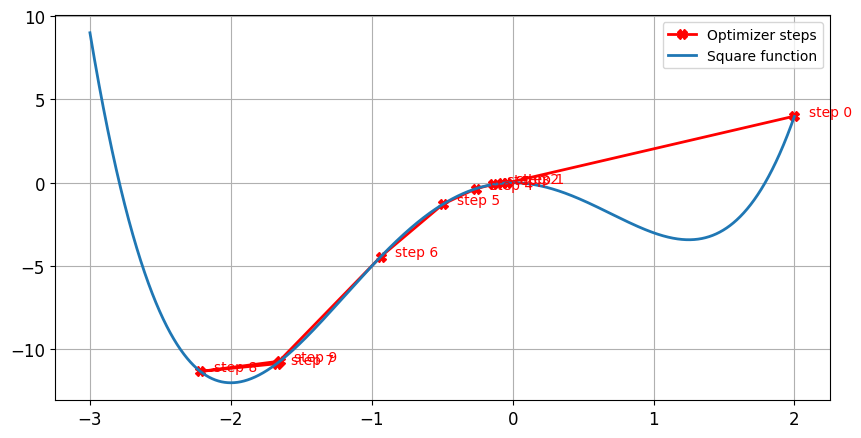

In [ ]:
def optimize_and_plot(lr=0.01, momentum=0.0):
    x = torch.tensor(2.0, requires_grad=True)
    buffer = torch.zeros_like(x.data)
    values = []
    for i in range(10):

        y = function(x)
        values.append((x.detach().clone(), y.detach().clone()))

        y.backward()

        d_p = x.grad.data
        if momentum !=0 :
            buffer.mul_(momentum).add_(d_p)
            d_p = buffer

        x.data.add_(d_p, alpha=-lr)
        x.grad.zero_()

    x = np.arange(-3, 2, 0.001)
    y = function(x)

    plt.figure(figsize=(10, 5))
    plt.plot([v[0].detach().numpy() for v in values], [v[1].detach().numpy() for v in values], 'r-X',
            linewidth=2, markersize=7)
    for i in range(10):
        plt.text(values[i][0]+0.1, values[i][1], f'step {i}', fontdict={'color': 'r'})
    plt.plot(x, y, linewidth=2)
    plt.grid()
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend(['Optimizer steps', 'Square function'])
    plt.show()

def function(x):
    return x**4 + x**3 - 5*x**2

# Try a third learning rate value
lr2 = 0.085
optimize_and_plot(lr=lr2)

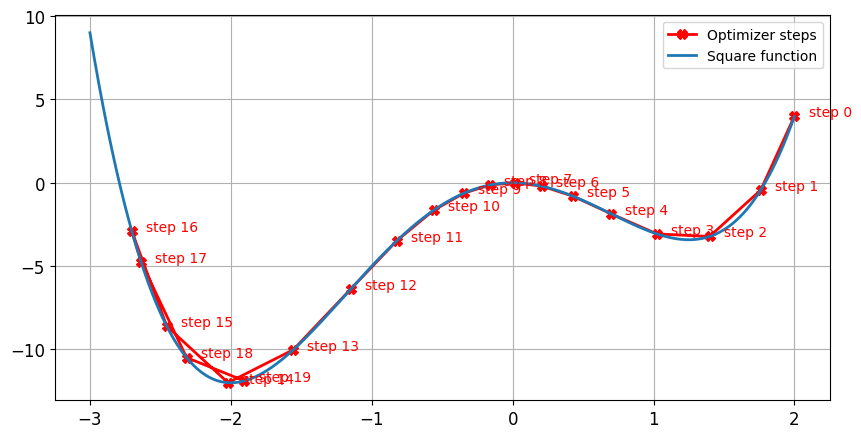

In [ ]:
def optimize_and_plot(lr=0.01, momentum=0.0):
  if lr > 0.05:
    raise ValueError('Choose a learning <= 0.05')
  x = torch.tensor(2.0, requires_grad=True)
  buffer = torch.zeros_like(x.data)
  values = []
  for i in range(20):

      y = function(x)
      values.append((x.detach().clone(), y.detach().clone()))
      y.backward()

      d_p = x.grad.data
      if momentum !=0 :
          buffer.mul_(momentum).add_(d_p)
          d_p = buffer

      x.data.add_(d_p, alpha=-lr)
      x.grad.zero_()

  x = np.arange(-3, 2, 0.001)
  y = function(x)

  plt.figure(figsize=(10, 5))
  plt.plot([v[0].detach().numpy() for v in values], [v[1].detach().numpy() for v in values], 'r-X',
           linewidth=2, markersize=7)
  for i in range(20):
      plt.text(values[i][0]+0.1, values[i][1], f'step {i}', fontdict={'color': 'r'})
  plt.plot(x, y, linewidth=2)
  plt.grid()
  plt.tick_params(axis='both', which='major', labelsize=12)
  plt.legend(['Optimizer steps', 'Square function'])
  plt.show()

def function(x):
    return x**4 + x**3 - 5*x**2

# Try a second value for momentum
mom1 = 0.95
optimize_and_plot(momentum=mom1)

A good rule of thumb is to start with a learning rate of 0.001 and a momentum of 0.95.

# **Layer initialization and transfer learning**

In [ ]:
from torch.nn import Linear

layer = Linear(64, 128)
print(layer.weight.min(),'\n',layer.weight.max())


tensor(-0.1249, grad_fn=<MinBackward1>) 
 tensor(0.1250, grad_fn=<MaxBackward1>)


## **Layer weight initialization with uniform distribution $U(0, 1)$**

In [ ]:
from torch.nn.init import uniform_

layer = Linear(64, 128)
uniform_(layer.weight)

print(layer.weight.min(),'\n',layer.weight.max())

tensor(0.0001, grad_fn=<MinBackward1>) 
 tensor(0.9999, grad_fn=<MaxBackward1>)


## **Transfer Learning**

Reuse a model trained on the first task for the second similar task

In [33]:
import torch
from torch.nn import Linear
from torch.serialization import add_safe_globals

# Allow unpickling of this class
add_safe_globals([Linear])

layer = Linear(64, 128)
torch.save(layer, "layer.pth")
new_layer = torch.load("layer.pth", weights_only=False)
new_layer


Linear(in_features=64, out_features=128, bias=True)

## **Fine tuning**

- Smaller learning rate
- can choose to train only some part of network
- Rule of thumb: freeze early layers of network and fine-tune layers closer to output layer

In [ ]:
from torch.nn import Linear, Sequential

model = Sequential(Linear(64, 128), Linear(128, 256))

for name, param in model.named_parameters():
    if name == '0.weight':
        param.requires_grad = False

#### ***Exercise: Freeze layers of a model***

You are about to fine-tune a model on a new task after loading pre-trained weights. The model contains three linear layers. However, because your dataset is small, you only want to train the last linear layer of this model and freeze the first two linear layers.

The model has already been created and exists under the variable `model`. You will be using the `named_parameters` method of the model to list the parameters of the model. Each parameter is described by a name. This name is a string with the following naming convention: `x.name` where `x` is the index of the layer.

Remember that a linear layer has two parameters: the `weight` and the `bias`.

#### Instructions

- Use an `if` statement to check if a parameter is a `weight` from the first or second layer.
- Freeze the weights of the first two layers of this model.


In [34]:
from torch.nn import Sequential, Linear

model = Sequential(Linear(8, 16), Linear(16, 32), Linear(32, 10))

for name, param in model.named_parameters():

    # Check for first layer's weight
    if name == '0.weight':

        # Freeze this weight
        param.requires_grad = False

    # Check for second layer's weight
    if name == '1.weight':

        # Freeze this weight
        param.requires_grad = False


#### ***Exercise: Layer initialization***

The initialization of the weights of a neural network has been the focus of researchers for many years. When training a network, the method used to initialize the weights has a direct impact on the final performance of the network.

As a machine learning practitioner, you should be able to experiment with different initialization strategies. In this exercise, you are creating a small neural network made of two layers and you are deciding to initialize each layer's weights with the uniform method.

#### ***Instructions***

- For each layer (`layer0` and `layer1`), use the uniform initialization method to initialize the weights.

In [ ]:
from torch.nn import Linear, Sequential
from torch.nn.init import uniform_


layer0 = Linear(16, 32)
layer1 = Linear(32, 64)

# Use uniform initialization for layer0 and layer1 weights
uniform_(layer0.weight)
uniform_(layer1.weight)

model = Sequential(layer0, layer1)

# **Evaluate model**

## **Calculate training loss**

For each epoch:

- sum the loss across all batches in dataloader

In [ ]:
from torch.nn import CrossEntropyLoss, Linear, Sequential

criterion = CrossEntropyLoss()
model = Sequential(Linear(64, 128), Linear(128, 256))

training_loss = 0.0

for inputs, labels in trainloader:
    # Run the forward pass
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    # Backpropagation
    loss.backward() # Compute gradients
    optimizer.step() # Update weights
    optimizer.zero_grad() # Reset gradients

    # Calculate and sum the loss
    training_loss += loss.item()

epoch_loss = training_loss / len(trainloader)

## **Calculating validation loss**

In [ ]:
validation_loss = 0.0
model.eval() # Put model in evaluation mode

with torch.no_grad(): # Disable gradients for efficiency since we don't update weights during validation
    for inputs, labels in validationloader:

        # Run the forward pass
        outputs = model(inputs)

        # Calculate the loss
        loss = criterion(outputs, labels)
        validation_loss += loss.item()

epoch_loss = validation_loss / len(validationloader) # Compute mean loss
model.train() # Switch back to training mode

## **Overfitting**

- Occur when validation loss increases

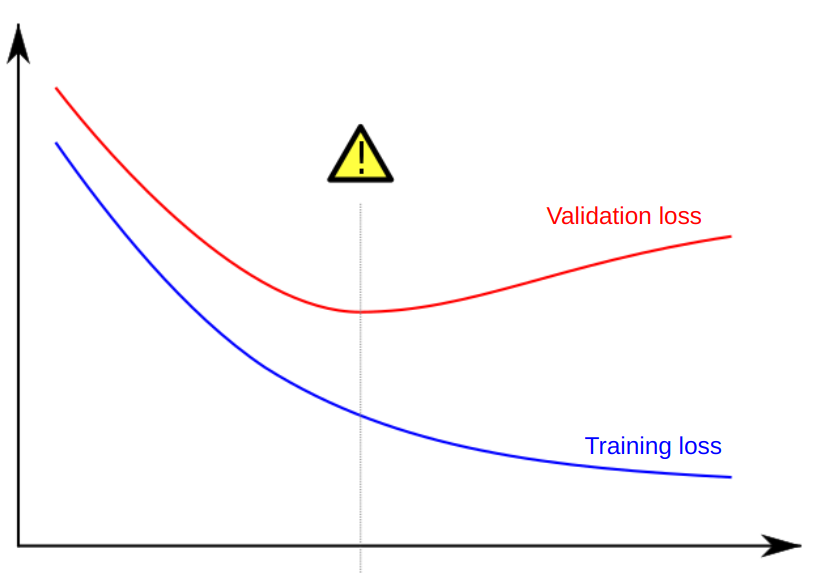

## **Calculating accuracy**

In [ ]:
import torchmetrics

# Create accuracy metric
metric = torchmetrics.Accuracy(task="multiclass", num_classes=3)

for features, labels in dataloader:
    outputs = model(features) # Forward pass

    # Compute batch accuracy (keeping argmax for one-hot labels)
    metric.update(outputs, labels.argmax(dim=-1))

# Compute accuracy over the whole epoch
accuracy = metric.compute()

# Reset metric for the next epoch
metric.reset()


#### ***Exercise: Writing the evaluation loop***

In this exercise, you will write an evaluation loop to compute validation loss. The evaluation loop follows a similar structure to the training loop but without gradient calculations or weight updates.

`model`, `validationloader`, and loss function `criterion` have already been defined to handle predictions, data loading, and loss calculation.

#### Instructions

- Set the model to evaluation mode.
- Sum the current batch loss to the `validation_loss` variable.
- Calculate the mean loss value for the epoch.
- Set the model back to training mode.

In [ ]:
from torch import tensor
from torch.nn import Sequential, Linear, CrossEntropyLoss
from torch.utils.data import TensorDataset, DataLoader

df = pd.read_csv('water_potability.csv')

X = df.iloc[:, 1:-1].to_numpy()
y = df.iloc[:, -1].to_numpy()
dataset = TensorDataset(torch.tensor(X, dtype=torch.float32),
                        torch.tensor(y, dtype=torch.long))  # must be long
validationloader = DataLoader(dataset, batch_size=8, shuffle=True)

model = Sequential(Linear(8, 4), Linear(4, 2))
criterion = CrossEntropyLoss()
####################################################################
# Set the model to evaluation mode
model.eval()
validation_loss = 0.0

with torch.no_grad():
  for features, labels in validationloader:
      outputs = model(features)
      loss = criterion(outputs, labels)
      # Sum the current loss to the validation_loss variable
      validation_loss += loss.item()

# Calculate the mean loss value
validation_loss_epoch = validation_loss / len(validationloader)
print(validation_loss_epoch)

# Set the model back to training mode
model.train()


0.6758471888209147


Sequential(
  (0): Linear(in_features=8, out_features=4, bias=True)
  (1): Linear(in_features=4, out_features=2, bias=True)
)

#### ***Exercise: Calculating accuracy using torchmetrics***

Tracking accuracy during training helps identify the best-performing epoch.

In this exercise, you'll use `torchmetrics` to calculate accuracy on a **facemask dataset** with three classes. The `plot_errors` function will highlight misclassified samples, helping you analyze model errors.

`torchmetrics` package is already imported. Model `outputs` are softmax probabilities, and `labels` are one-hot encoded vectors.

#### **Instructions**

* Create a `"multiclass"` accuracy metric with three classes.
* Calculate the accuracy for each batch of the dataloader.
* Calculate accuracy for the epoch.
- Reset the metric for the next epoch.

In [29]:
import pandas as pd, torchmetrics, matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import Sequential, Flatten, Linear
from torchvision.transforms import Normalize
from torch import tensor

X, y = pd.read_pickle("/content/masks_dataset.pickle")
X = X.transpose(0, 3, 1, 2)  # Convert (N, H, W, C) → (N, C, H, W)
dataset = TensorDataset(tensor(X, dtype=torch.float32), tensor(y, dtype=torch.long))
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Construct by looking at model object
model = Sequential(Normalize(mean=[0.51378129, 0.44999619, 0.42258797],
                             std=[0.25081163, 0.24213039, 0.24616128]),
                   Flatten(start_dim=1, end_dim=-1),
                   Linear(in_features=3072, out_features=3, bias=True))

In [30]:
from mpl_toolkits.axes_grid1.axes_grid import ImageGrid

def plot_errors(model, dataloader):
    # find mismatches
    mismatches = []
    for data in dataloader:
        if len(mismatches) > 8:
            break
        features, labels = data
        outputs = model(features)
        gt = labels
        pred = outputs.argmax(-1)
        for f, g, p in zip(features, gt, pred):
            if g != p:
                mismatches.append((f, g, p))


    fig = plt.figure(figsize=(8, 8))
    grid = ImageGrid(fig, 111,  # similar to subplot(111)
                     nrows_ncols=(2, 4),  # creates 2x2 grid of axes
                     axes_pad=0.5,  # pad between axes in inch.
                     )
    mapping = {0: 'No mask', 1: 'Mask', 2: 'Incorrect'}
    for idx, ax in enumerate(grid):
        ax.imshow(mismatches[idx][0].permute(1, 2, 0))
        ax.set_title(f'GT: {mapping[mismatches[idx][1].item()]} \n PRED: {mapping[mismatches[idx][2].item()]}')
        ax.axis('off')
    plt.show()

Accuracy on all data: 0.3323943614959717


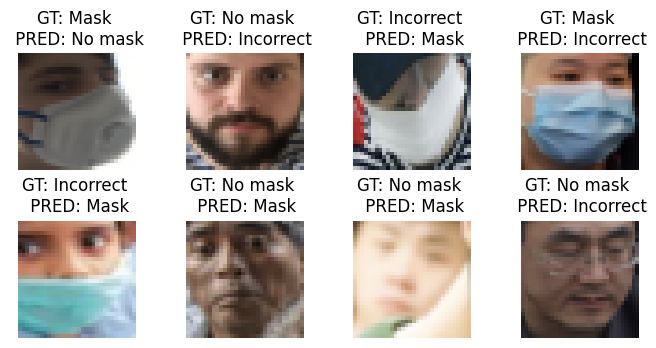

In [32]:
# Create accuracy metric
metric = torchmetrics.Accuracy(task="multiclass", num_classes=3)
for features, labels in dataloader:
    outputs = model(features)

    # Calculate accuracy over the batch
    metric.update(outputs, labels)

# Calculate accuracy over the whole epoch
accuracy = metric.compute()
print(f"Accuracy on all data: {accuracy}")

# Reset metric for the next epoch
metric.reset()
plot_errors(model, dataloader)

# **Overfitting**

| **Problem** | **Solution** |
|--------------|--------------|
| Dataset is not large enough | Get more data / use data augmentation |
| Model has too much capacity | Reduce model size / add dropout |
| Weights are too large | Apply weight decay |


## **Regularization using a dropout layer**

- Dropout is added ***after*** the activation function

In [8]:
from torch.nn import Sequential, Linear, ReLU, Dropout
from torch import randn

model = Sequential(Linear(8, 4), ReLU(), Dropout(p=0.5))
features = randn((1, 8))
print(model(features))

tensor([[0.0000, 1.0598, 0.5574, 0.0000]], grad_fn=<MulBackward0>)


## **Regularization with weight decay**

- The higher the `weight_decay`, the stronger regularization, making overfitting less likely.

In [9]:
from torch import optim

optimizer = optim.SGD(model.parameters(), lr=0.001, weight_decay=0.0001)

#### ***Exercise: Experimenting with dropout***

Dropout helps prevent overfitting by randomly setting some output values to zero during training. In this exercise, you'll build a simple neural network with dropout and observe how it behaves in training and evaluation modes.

#### **Instructions**

- Add a dropout layer to the model with a 50% probability of zeroing out elements.
- Set the model to training mode and generate predictions using `features`, storing the output as `output_train`.
- Set the model to evaluation mode to disable dropout.
- Generate predictions using `features`, storing the output as `output_eval`.

In [10]:
from torch import tensor
from torch.nn import Sequential, Linear, Dropout

features = tensor([[-0.8627, -0.4874, -0.8308, -1.1455, -0.8533,  0.8255,  0.3256,  0.5113]])

model = Sequential(Linear(8, 6), Linear(6, 4), Dropout(p=0.5))

model.train()
output_train = model(features)

# Forward pass in evaluation mode (Dropout disabled)
model.eval()
output_eval = model(features)

# Print results
print("Output in train mode:", output_train)
print("Output in eval mode:", output_eval)

Output in train mode: tensor([[-0.1154,  0.0000, -0.3271,  0.0000]], grad_fn=<MulBackward0>)
Output in eval mode: tensor([[-0.0577,  0.0536, -0.1635,  0.5094]], grad_fn=<AddmmBackward0>)


# **Improving performance**

## **Step 1: overfit the training set**

- Modify the training loop to overfit a ***single data point***
- Should reach 1.0 accuracy and 0 loss
- Then scale up to the entire training set
  - Keep default hyperparameters

In [ ]:
features, labels = next(iter(dataloader))
for i in range(1000):
    outputs = model(features)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

## **Step 2: reduce overfitting**

**Goal**: maximize the validation accuracy
- Experiment with:
  - Dropout
  - Data augmentation
  - Weight decay
  - Reducing model capacity

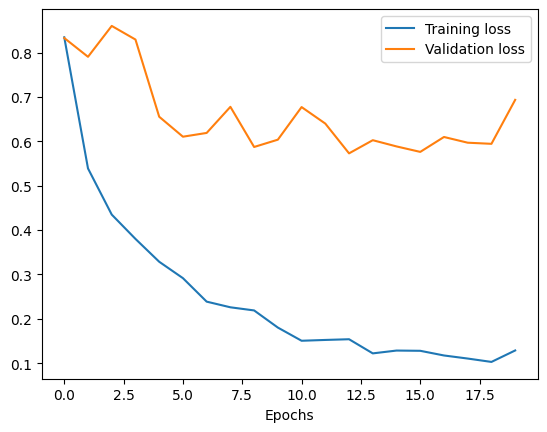

## **Step 3: fine-tune hyperparameters**

* Grid Search
* Random Search

#### ***Exercise: Implementing random search***

Hyperparameter search is a computationally costly approach to experiment with different hyperparameter values. However, it can lead to performance improvements. In this exercise, you will implement a random search algorithm.

You will randomly sample 10 values of the learning rate and momentum from the uniform distribution. To do so, you will use the **`np.random.uniform()`** function.

#### ***Instructions***

- Randomly sample a learning rate factor between `2` and `4` so that the learning rate (`lr`) is bounded between $10^{-2}$  and $10^{-4}$
.
- Randomly sample a momentum between 0.85 and 0.99.

In [11]:
def plot_hyperparameter_search(values):
    lrs, momentums = zip(*values)

    plt.figure(figsize=(8, 6))
    plt.scatter(lrs, momentums)
    plt.xscale("log")  # Use log scale for learning rate
    plt.xlabel("Learning Rate")
    plt.ylabel("Momentum")
    # plt.title("Randomly Sampled Learning Rates and Momentum")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Set specific tick marks on the x-axis
    plt.xticks([10**-2, 10**-3, 10**-4],
               [r'$10^{-2}$', r'$10^{-3}$', r'$10^{-4}$'])

    plt.show()

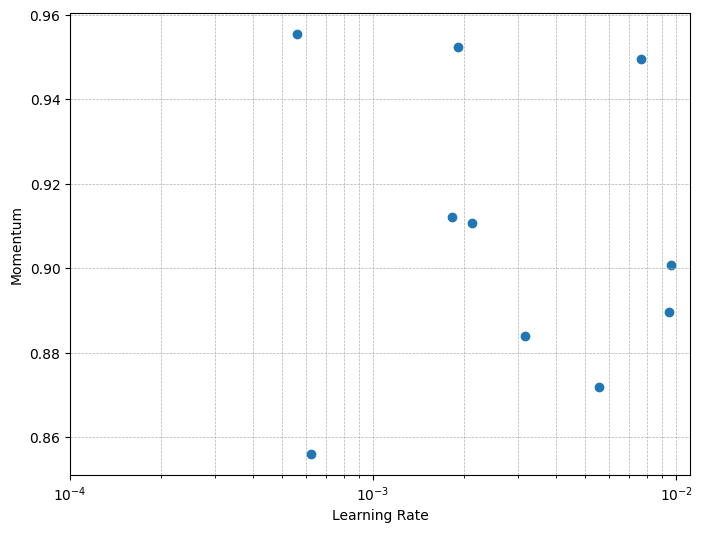

In [12]:
values = []
for idx in range(10):
    # Randomly sample a learning rate factor between 2 and 4
    factor = np.random.uniform(2, 4)
    lr = 10 ** -factor

    # Randomly select a momentum between 0.85 and 0.99
    momentum = np.random.uniform(0.85, 0.99)

    values.append((lr, momentum))

plot_hyperparameter_search(values)